# 13. Conclusiones finales y resultados

Este notebook reúne los resultados finales del estudio de pseudo-LiDAR sobre nuScenes, con foco en el registro temporal orientado a tareas tipo SLAM.

Pregunta principal:
- ¿La pseudo-LiDAR generada a partir de 6 cámaras puede ser útil para registrar frames consecutivos?
- ¿Qué selección espacial y qué estrategia de registro funcionan mejor?


In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image

pd.options.display.float_format = '{:.3f}'.format
plt.style.use('default')

ROOT = Path('/home/clara/ml-depth-pro/slam_readiness_nuscenes')
BASE_DIR = ROOT / 'outputs' / 'scene-0061'

subset = json.loads((BASE_DIR / 'subset_registration_comparison.json').read_text())
front_best = json.loads((BASE_DIR / 'front_best_combination.json').read_text())
traj = json.loads((BASE_DIR / 'accumulated_trajectory_comparison.json').read_text())
point_sel = json.loads((BASE_DIR / 'front_point_selection_comparison.json').read_text())
param_sweep = json.loads((BASE_DIR / 'front_global_icp_param_sweep.json').read_text())

trajectory_png = BASE_DIR / 'accumulated_trajectory_xy.png'
drift_png = BASE_DIR / 'accumulated_trajectory_drift.png'
pc_best_png = BASE_DIR / 'pointcloud_comparison_best_cfg05.png'
pc_narrow_png = BASE_DIR / 'pointcloud_comparison_narrow_cfg05.png'


## 1. Comparación final de registro por parejas

Este primer bloque compara las configuraciones principales después de todo el proceso de ajuste. Las métricas más relevantes son:
- `translation_error_mean_m`,
- `rotation_error_mean_deg`.

En una lectura orientada a SLAM, valores más bajos indican un mejor comportamiento.


In [2]:
subset_agg = subset['aggregate']
front_best_agg = front_best['aggregate']

main_rows = [
    {
        'configuracion': 'all',
        **subset_agg['all'],
    },
    {
        'configuracion': 'front',
        **subset_agg['front'],
    },
    {
        'configuracion': 'front_baseline_cfg05',
        **front_best_agg['front_baseline_cfg05'],
    },
    {
        'configuracion': 'front_narrow_cfg05',
        **front_best_agg['front_narrow_cfg05'],
    },
]

main_df = pd.DataFrame(main_rows).set_index('configuracion')
display(main_df)


,translation_error_mean_m,rotation_error_mean_deg,fitness_mean,num_valid_pairs,rmse_mean
configuracion,,,,,
all,2.179,3.594,0.799,4,NaN
front,1.906,2.330,0.752,4,NaN
front_baseline_cfg05,1.179,1.598,0.748,4,0.620
front_narrow_cfg05,1.223,1.680,0.800,4,0.609


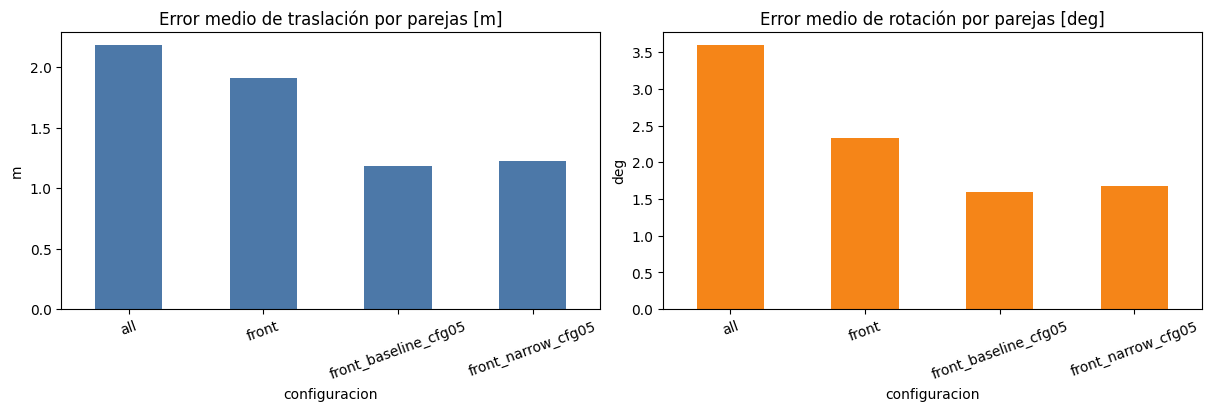

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

main_df['translation_error_mean_m'].plot(kind='bar', ax=axes[0], color='#4C78A8', title='Error medio de traslación por parejas [m]')
axes[0].set_ylabel('m')
axes[0].tick_params(axis='x', rotation=20)

main_df['rotation_error_mean_deg'].plot(kind='bar', ax=axes[1], color='#F58518', title='Error medio de rotación por parejas [deg]')
axes[1].set_ylabel('deg')
axes[1].tick_params(axis='x', rotation=20)

plt.show()


## 2. Qué ha mejorado durante el ajuste

En esta sección se resumen las dos fases principales de ajuste:
- selección de puntos en la región frontal,
- barrido de parámetros para alineación global + ICP.


In [4]:
point_rows = [{'seleccion_puntos': name, **metrics} for name, metrics in point_sel['aggregate'].items()]
point_rows = sorted(point_rows, key=lambda r: (r['translation_error_mean_m'], r['rotation_error_mean_deg']))
point_df = pd.DataFrame(point_rows).set_index('seleccion_puntos')

cfg_rows = []
for cfg in param_sweep['configs']:
    cfg_rows.append({
        'name': cfg['name'],
        'coarse_voxel': cfg['coarse_voxel'],
        'global_corr': cfg['global_corr'],
        'fine_voxel': cfg['fine_voxel'],
        'icp_corr': cfg['icp_corr'],
        **cfg['aggregate'],
    })
cfg_rows = sorted(cfg_rows, key=lambda r: (r['translation_error_mean_m'], r['rotation_error_mean_deg']))[:5]
top_cfg_df = pd.DataFrame(cfg_rows).set_index('name')

print('Comparación de selección de puntos')
display(point_df)

print('Top 5 configuraciones de global+ICP')
display(top_cfg_df)


Comparación de selección de puntos


,translation_error_mean_m,rotation_error_mean_deg,fitness_mean,rmse_mean,num_valid_pairs
seleccion_puntos,,,,,
front_narrow,1.249,1.590,0.800,0.613,4
front_baseline,1.450,2.985,0.753,0.640,4
front_compact,1.529,1.840,0.760,0.616,4
front_midrange,2.042,2.750,0.740,0.629,4
front_above_ground,6.537,46.224,0.721,0.689,4


Top 5 configuraciones de global+ICP


,coarse_voxel,global_corr,fine_voxel,icp_corr,translation_error_mean_m,rotation_error_mean_deg,fitness_mean,rmse_mean,num_valid_pairs
name,,,,,,,,,
cfg_05,0.800,2.000,0.400,1.500,1.175,1.607,0.748,0.620,4
cfg_01,0.800,1.600,0.400,1.500,1.182,1.609,0.748,0.619,4
cfg_03,0.800,1.600,0.500,1.500,1.302,1.800,0.748,0.637,4
cfg_11,1.000,1.600,0.500,1.500,1.310,1.800,0.748,0.637,4
cfg_07,0.800,2.000,0.500,1.500,1.327,1.785,0.749,0.637,4


## 3. Trayectoria acumulada

El registro por parejas resulta informativo, pero una evaluación más cercana a SLAM requiere analizar también qué ocurre cuando los errores se acumulan a lo largo de la secuencia.

Por ello, la cuestión central en este bloque es si una configuración se mantiene estable a lo largo de 5 frames, y no únicamente si alinea bien una sola pareja.


In [5]:
traj_rows = []
for name, payload in traj['trajectories'].items():
    agg = payload['aggregate']
    traj_rows.append({
        'estrategia': name,
        **agg,
    })
traj_df = pd.DataFrame(traj_rows).set_index('estrategia')
display(traj_df)

print('Mejor recomendación según trayectoria acumulada:', traj['best_recommendation'])


,mean_translation_error_m,mean_rotation_error_deg,final_translation_error_m,final_rotation_error_deg,num_frames
estrategia,,,,,
front_icp_only,4.716,5.206,6.583,5.526,5
front_baseline_cfg05,2.060,2.856,3.913,3.709,5
front_narrow_cfg05,1.683,3.272,4.289,5.071,5


Mejor recomendación según trayectoria acumulada: front_baseline_cfg05


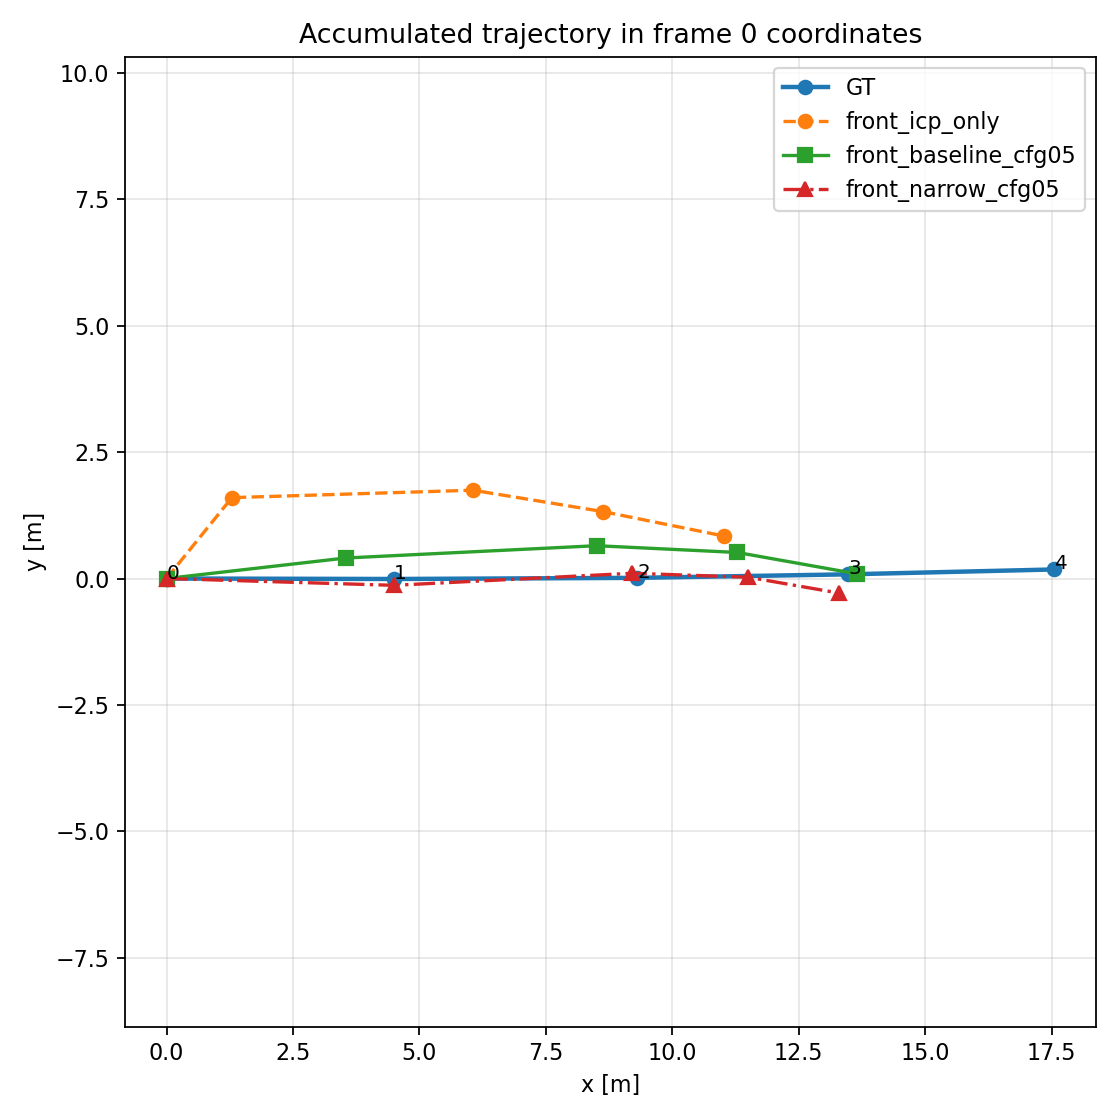

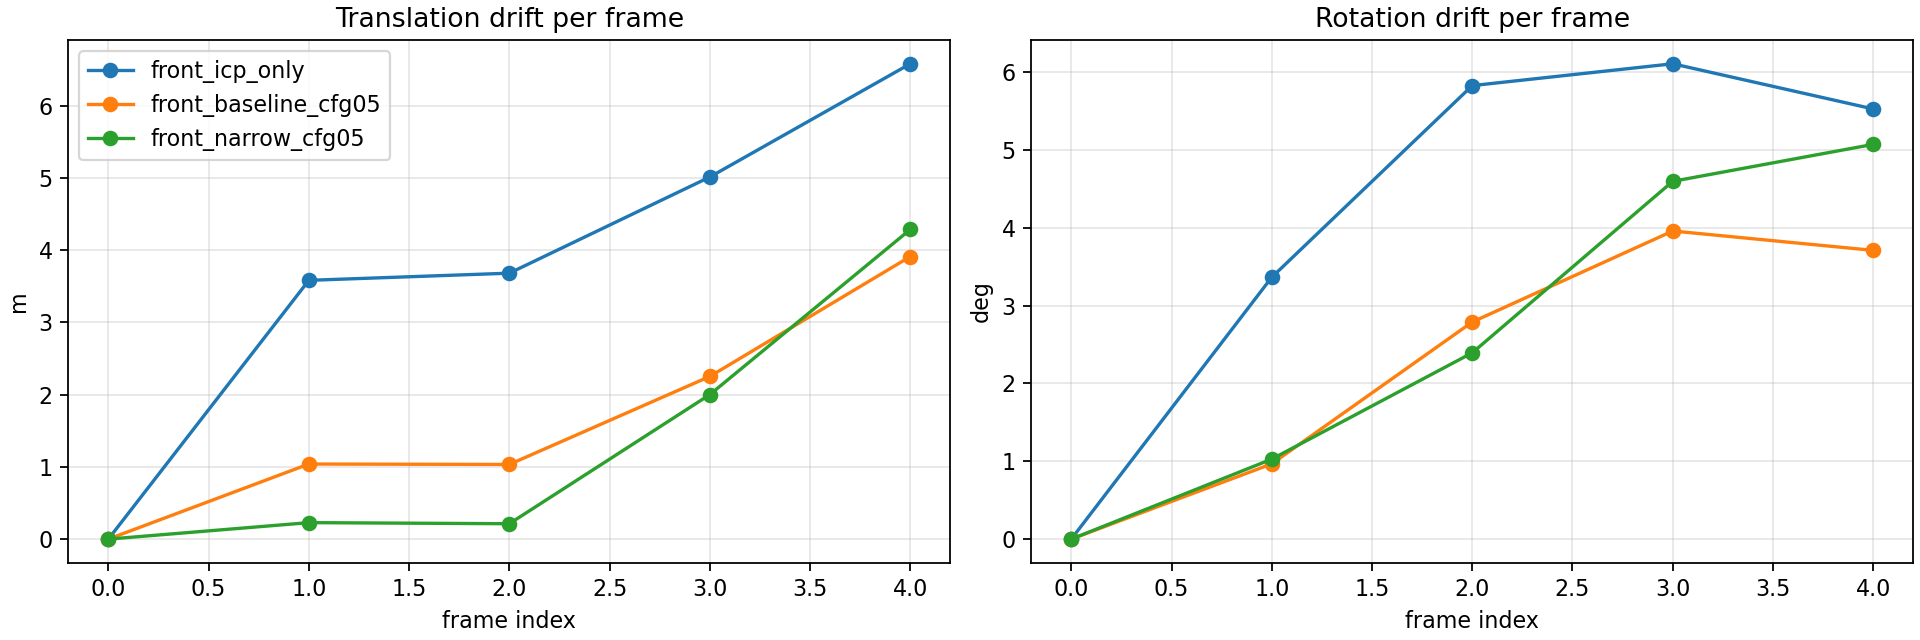

In [6]:
display(Image(filename=str(trajectory_png)))
display(Image(filename=str(drift_png)))


## 4. Comparación de nubes de puntos

Estas superposiciones permiten interpretar visualmente las métricas obtenidas.
- `front_baseline_cfg05` es la configuración más estable para trayectoria acumulada.
- `front_narrow_cfg05` puede ofrecer ajustes más compactos en algunas parejas locales, pero tiende a derivar más cuando las transformaciones se acumulan.


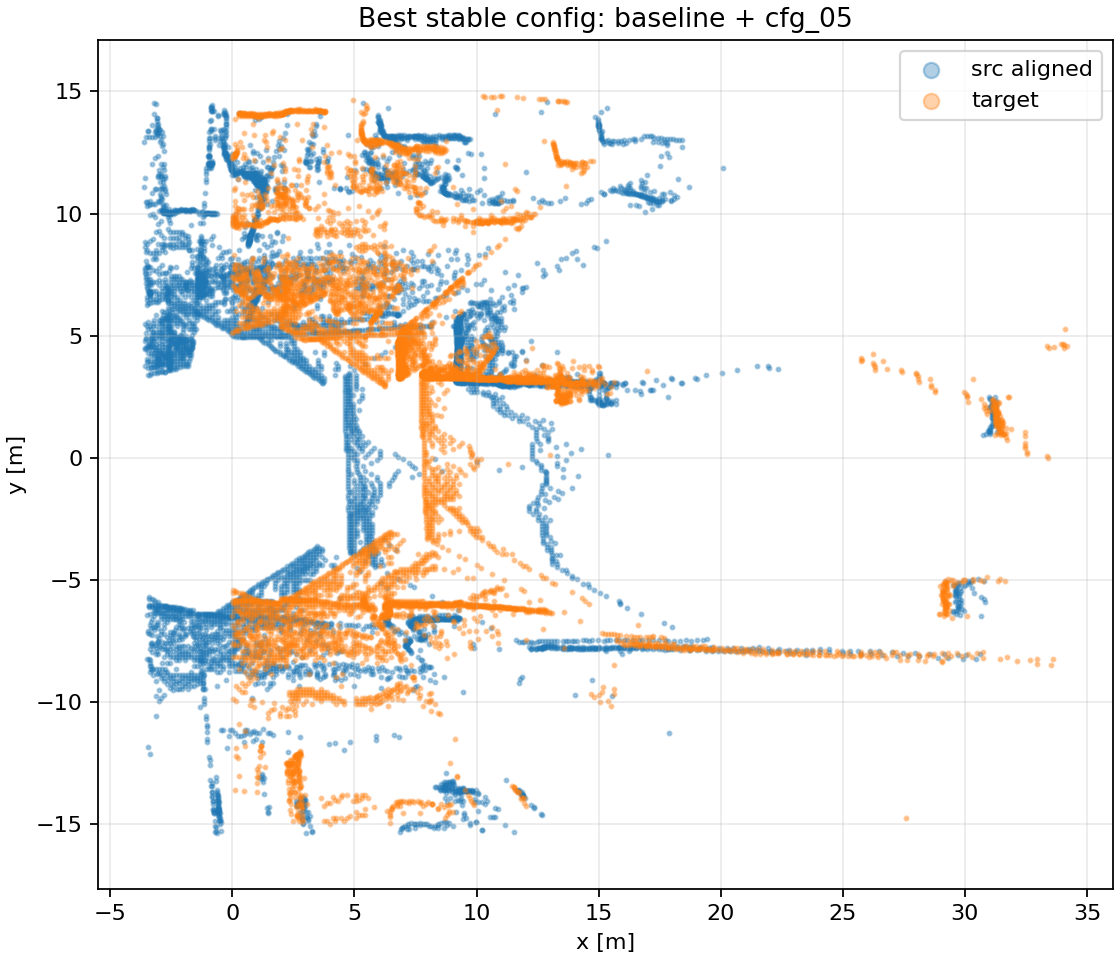

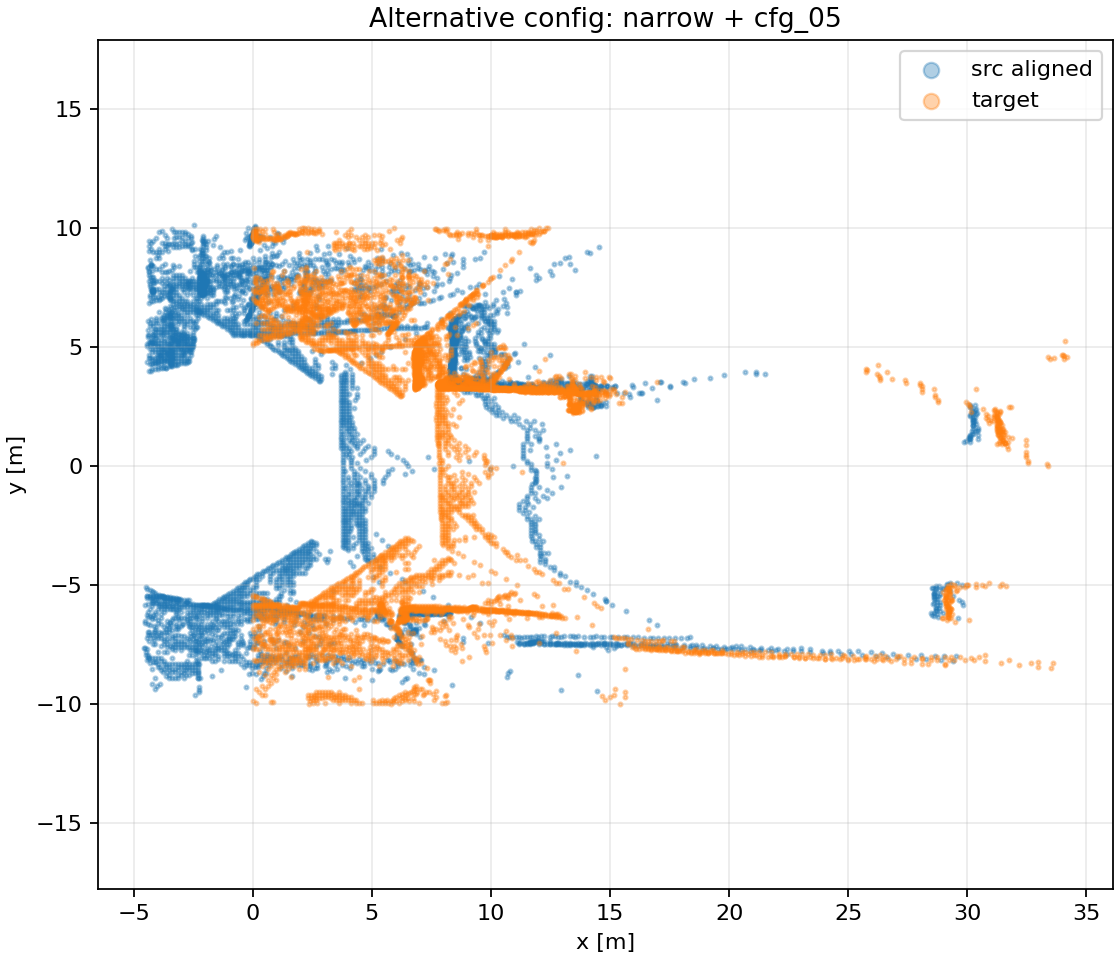

In [7]:
display(Image(filename=str(pc_best_png)))
display(Image(filename=str(pc_narrow_png)))


## 5. Conclusiones finales

- El anillo 360 de pseudo-LiDAR puede reconstruirse a partir de las 6 cámaras de nuScenes, pero no ofrece la misma fiabilidad en todas las regiones para el registro temporal.
- El uso del anillo completo no constituye la mejor opción para un registro tipo SLAM. Restringir la nube a la región frontal mejora de manera consistente los resultados.
- El ajuste adicional muestra que la mejor configuración global es `front_baseline_cfg05`, no porque sea siempre la mejor en cada pareja, sino porque es la más estable cuando el error de trayectoria se acumula.
- `front_narrow_cfg05` puede conseguir alineamientos locales muy buenos en algunas parejas, pero resulta menos robusta a lo largo de la secuencia completa.
- La lectura final, por tanto, es matizada: la pseudo-LiDAR no sustituye a un LiDAR real para un SLAM robusto, pero sí aporta información geométrica útil para el registro temporal cuando se utiliza de forma selectiva y con una estrategia de alineación adecuada.

### Configuración final recomendada

- Subconjunto espacial: `front_baseline`
- Registro: alineación global + ICP
- Mejor conjunto de parámetros: `cfg_05`

### Mensaje principal del proyecto

La pseudo-LiDAR generada a partir de cámaras puede ser útil para registro temporal tipo SLAM, pero su valor depende de forma clara de qué parte de la nube se utilice y de cómo se inicialice el proceso de registro.
